<a href="https://colab.research.google.com/github/neelmulayPenn/U-Net-Semantic-Segmentation/blob/main/SegFormer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import Cityscapes
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F



In [ ]:
import jax
import jax.numpy as jnp

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt


In [ ]:
model_name = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"

feature_extractor = SegformerFeatureExtractor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)
model.eval()  # inference mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/segformer/feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/models/segformer/feature_extraction_segformer.py:35: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  super().__init__(*args, **kwargs)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/339M [00:00<?, ?B/s]

cuda


In [ ]:
# official rawID -> trainId mapping for Cityscapes
id_to_trainId = {
    0:255, 1:255, 2:255, 3:255, 4:255, 5:255, 6:255,
    7:0, 8:1, 9:255, 10:255, 11:2, 12:3, 13:4,
    14:255, 15:255, 16:255, 17:5, 18:255, 19:6, 20:7,
    21:8, 22:9, 23:10, 24:11, 25:12, 26:13, 27:14,
    28:15, 29:255, 30:255, 31:16, 32:17, 33:18, -1:255
}

def mask_to_trainId(mask_np):
    mask_mapped = np.ones_like(mask_np) * 255
    for k,v in id_to_trainId.items():
        mask_mapped[mask_np == k] = v
    return mask_mapped

In [ ]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import Cityscapes

import albumentations as A
from albumentations.pytorch import ToTensorV2

# -----------------------
# 1. Define joint transform
# -----------------------
train_transform = A.Compose([
    A.Resize(1024, 2048),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# -----------------------
# 2. Wrapper dataset so Albumentations can work with torchvision
# -----------------------
class CityscapesDataset(torch.utils.data.Dataset):
    def __init__(self, root, split, transform):
        self.dataset = Cityscapes(
            root=root,
            split=split,
            mode="fine",
            target_type="semantic"
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]  # PIL images

        img_np = np.array(img)
        mask_np = np.array(mask)  # shape (H, W) with class indices
        mask_np = mask_to_trainId(mask_np)

        transformed = self.transform(image=img_np, mask=mask_np)

        return transformed["image"], transformed["mask"].long()


# -----------------------
# 3. Create Datasets
# -----------------------
ROOT = "/content/drive/MyDrive/MEAM_5310/Cityscapes"    # adjust if needed

train_dataset = CityscapesDataset(ROOT, split="train", transform=train_transform)
val_dataset   = CityscapesDataset(ROOT, split="val",   transform=val_transform)

# -----------------------
# 4. DataLoaders
# -----------------------
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0, pin_memory=True)


In [ ]:
def predict(model, dataloader, device):
    model.eval()
    preds, gts = [], []

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)

            outputs = model(pixel_values=imgs)
            logits = outputs.logits

            # 🔴 CRITICAL: upsample to GT resolution
            logits = torch.nn.functional.interpolate(
                logits,
                size=masks.shape[1:],
                mode="bilinear",
                align_corners=False
            )

            preds.append(logits.argmax(dim=1).cpu())  # (B, H, W)
            gts.append(masks.cpu())                   # (B, H, W)

    preds = torch.cat(preds, dim=0)
    gts   = torch.cat(gts, dim=0)

    return preds, gts


In [ ]:
def visualize_segmentation(image_tensor, pred_mask, gt_mask):
    # Convert image tensor to numpy
    image_np = image_tensor.permute(1,2,0).cpu().numpy()
    image_np = (image_np * feature_extractor.image_std + feature_extractor.image_mean).clip(0,1)

    plt.figure(figsize=(18,6))
    plt.subplot(1,3,1)
    plt.imshow(image_np)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gt_mask)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask)
    plt.title("SegFormer Prediction")
    plt.axis("off")
    plt.show()


In [ ]:
import torch
import torch.nn.functional as F

def per_class_iou(model, dataloader, num_classes=19, ignore_index=255, device="cuda"):
    model.eval()

    intersection = torch.zeros(num_classes, device=device)
    union = torch.zeros(num_classes, device=device)

    with torch.no_grad():
        for images, labels in dataloader:

            # NHWC → NCHW if needed
            if images.ndim == 4 and images.shape[-1] == 3:
                images = images.permute(0, 3, 1, 2)

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            logits = outputs.logits  # (B, C, h, w)

            # 🔑 CRITICAL FIX: upsample logits to label resolution
            logits = F.interpolate(
                logits,
                size=labels.shape[-2:],  # (H, W)
                mode="bilinear",
                align_corners=False
            )

            preds = torch.argmax(logits, dim=1)  # (B, H, W)

            for cls in range(num_classes):
                pred_mask = preds == cls
                label_mask = labels == cls

                intersection[cls] += (pred_mask & label_mask).sum()
                union[cls] += (pred_mask | label_mask).sum()

    return (intersection / (union + 1e-10)).cpu()


In [ ]:
CITYSCAPES_CLASSES = [
    "road",
    "sidewalk",
    "building",
    "wall",
    "fence",
    "pole",
    "traffic light",
    "traffic sign",
    "vegetation",
    "terrain",
    "sky",
    "person",
    "rider",
    "car",
    "truck",
    "bus",
    "train",
    "motorcycle",
    "bicycle",
]


In [ ]:
iou = per_class_iou(
    model=model,
    dataloader=val_loader,
    num_classes=19,
    ignore_index=255,
    device=device
)

for cls, score in zip(CITYSCAPES_CLASSES, iou):
    print(f"{cls:15s}: {score:.4f}")

print("\nMean IoU:", iou.mean().item())


KeyboardInterrupt: 

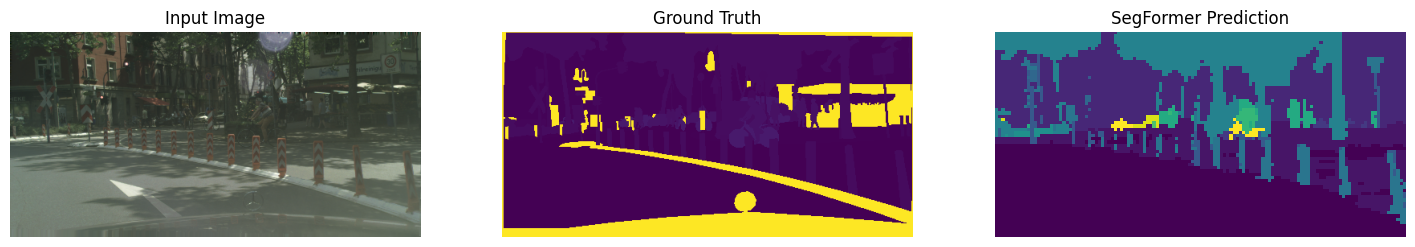

In [ ]:
# Take a single batch
for imgs, masks in val_loader:
    imgs = imgs.to(device)
    masks = masks
    outputs = model(pixel_values=imgs)
    logits = outputs.logits
    pred_mask = logits.argmax(dim=1).cpu().numpy()[0]

    visualize_segmentation(imgs[0], pred_mask, masks[0])
    break  # visualize first sample only


In [ ]:
!pip install torchmetrics
from torchmetrics import JaccardIndex

num_classes = 19  # Cityscapes (ignore label 255)

miou_metric = JaccardIndex(
    task="multiclass",
    num_classes=num_classes,
    average="macro"
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.8 MB/s eta 0:00:00


In [ ]:
NUM_CLASSES = 19
IGNORE_INDEX = 255

@jax.jit
def compute_miou(preds, masks, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    # Flatten
    preds = preds.ravel()
    masks = masks.ravel()

    valid = masks != ignore_index
    preds = preds[valid]
    masks = masks[valid]

    iou_per_class = []
    for cls in range(num_classes):
        pred_cls = preds == cls
        mask_cls = masks == cls
        intersection = jnp.sum(pred_cls & mask_cls)
        union = jnp.sum(pred_cls | mask_cls)
        iou_per_class.append(intersection / (union + 1e-6))

    return jnp.mean(jnp.stack(iou_per_class))


In [ ]:
import torch
import numpy as np

def compute_miou_torch(preds, masks, num_classes=19, ignore_index=255):
    """
    preds: (N, H, W) torch.Tensor
    masks: (N, H, W) torch.Tensor
    """
    preds = preds.view(-1)
    masks = masks.view(-1)

    valid = masks != ignore_index
    preds = preds[valid]
    masks = masks[valid]

    ious = []
    for cls in range(num_classes):
        pred_cls = preds == cls
        mask_cls = masks == cls

        intersection = (pred_cls & mask_cls).sum().item()
        union = (pred_cls | mask_cls).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    return np.mean(ious)


In [ ]:
import torch

class_weights = torch.tensor([
    1.0,   # 0 road
    1.2,   # 1 sidewalk
    1.0,   # 2 building
    1.5,   # 3 wall
    1.5,   # 4 fence
    2.0,   # 5 pole
    2.0,   # 6 traffic light
    2.0,   # 7 traffic sign
    1.2,   # 8 vegetation
    1.2,   # 9 terrain
    1.0,   # 10 sky
    1.5,   # 11 person
    1.5,   # 12 rider
    1.0,   # 13 car
    1.3,   # 14 truck
    1.3,   # 15 bus
    1.3,   # 16 train
    1.5,   # 17 motorcycle
    1.5    # 18 bicycle
]).to(device)


In [ ]:
CITYSCAPES_COLORS = torch.tensor([
    [128, 64,128], [244, 35,232], [ 70, 70, 70], [102,102,156],
    [190,153,153], [153,153,153], [250,170, 30], [220,220,  0],
    [107,142, 35], [152,251,152], [ 70,130,180], [220, 20, 60],
    [255,  0,  0], [  0,  0,142], [  0,  0, 70], [  0, 60,100],
    [  0, 80,100], [  0,  0,230], [119, 11, 32]
], dtype=torch.uint8)

def colorize_mask(mask):
    """ mask: (H, W) """
    h, w = mask.shape
    color = torch.zeros((h, w, 3), dtype=torch.uint8)
    valid = mask < 19
    color[valid] = CITYSCAPES_COLORS[mask[valid]]
    return color


In [ ]:
modelbefore = SegformerForSemanticSegmentation.from_pretrained(model_name)
modelbefore.to(device)
modelbefore.eval()
imgs_vis, masks_vis = next(iter(val_loader))
imgs_vis = imgs_vis.to(device)
masks_vis = masks_vis.to(device)

with torch.no_grad():
    outputs = modelbefore(pixel_values=imgs_vis)
    preds_before = torch.argmax(outputs.logits, dim=1)


In [ ]:
def compute_miou_single(pred, mask, num_classes=19, ignore_index=255):
    device = pred.device
    pred = pred.view(-1)
    mask = mask.view(-1)
    valid = mask != ignore_index
    pred = pred[valid]
    mask = mask[valid]

    iou_per_class = []
    for cls in range(num_classes):
        pred_cls = pred == cls
        mask_cls = mask == cls
        intersection = (pred_cls & mask_cls).sum().float()
        union = (pred_cls | mask_cls).sum().float()
        if union == 0:
            iou_per_class.append(torch.tensor(1.0, device=device))  # ensure same device
        else:
            iou_per_class.append(intersection / (union + 1e-6))
    return torch.mean(torch.stack(iou_per_class)).item()


In [ ]:
import torch
import numpy as np
import random

# pick a random index
idx = random.randint(0, len(val_dataset)-1)
img, mask = val_dataset[idx]

# add batch dimension
img = img.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)


model.eval()
with torch.no_grad():
    output = model(pixel_values=img).logits
    pred = torch.argmax(output, dim=1)  # shape: [1,H,W]

mask_resized = F.interpolate(mask.unsqueeze(1).float(), size=pred.shape[1:], mode='nearest').squeeze(1).long()


miou_one_image = compute_miou_single(pred, mask_resized)
print(f"mIoU for random image index {idx}: {miou_one_image:.4f}")


mIoU for random image index 277: 0.7390


In [ ]:
num_classes = 19
ignore_index = 255

def preprocess_mask(mask):
    # Ensure dtype
    mask = mask.long()

    # Map void pixels to ignore_index
    mask[mask == 255] = ignore_index

    # If labels are 1-based, subtract 1 for valid classes
    valid = mask != ignore_index
    mask[valid] = mask[valid] - 1

    return mask


In [ ]:
images, masks = next(iter(val_loader))

print("Mask dtype:", masks.dtype)
print("Mask shape:", masks.shape)
print("Mask min/max:", masks.min().item(), masks.max().item())
print("Mask unique:", torch.unique(masks))


Mask dtype: torch.int64
Mask shape: torch.Size([1, 256, 512])
Mask min/max: 0 255
Mask unique: tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,  11,  12,  13,  16,  18,
        255])


In [ ]:
import torch
import torch.nn.functional as F

def masked_cross_entropy_loss(
    logits,        # (B, C, H, W)
    labels,        # (B, H, W)
    num_classes=19,
    ignore_index=255,
):
    # logits -> (B, H, W, C)
    logits = logits.permute(0, 2, 3, 1)

    # flatten
    logits = logits.reshape(-1, num_classes)
    labels = labels.view(-1)

    # mask valid pixels
    valid = labels != ignore_index

    logits = logits[valid]
    labels = labels[valid]

    return F.cross_entropy(logits, labels)


In [ ]:
from torch.optim import AdamW


# Only fine-tune the model head (optional)
# Freeze encoder
for p in model.segformer.encoder.parameters():
    p.requires_grad = False

# Optimizer only sees decoder
optimizer = AdamW(
    model.decode_head.parameters(),
    lr=5e-4
)
#optimizer = AdamW(model.parameters(), lr=1e-5)
criterion = torch.nn.CrossEntropyLoss(ignore_index=255)

epochs = 3
model.train()

# for imgs, masks in val_loader:
#     masks[masks > 18] = 255  # 19 classes, ignore out-of-range
#     masks = masks.long()
#     imgs = imgs.float()

#     print("imgs shape:", imgs.shape, "dtype:", imgs.dtype, "min/max:", imgs.min(), imgs.max())
#     print("masks shape:", masks.shape, "dtype:", masks.dtype, "min/max:", masks.min(), masks.max())
#     break

# num_invalid = ((masks >= 19) | (masks < 0)).sum().item()
# print("Invalid mask pixels:", num_invalid)

for epoch in range(epochs):
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
    for imgs, masks in loop:

        masks[(masks < 0) | (masks >= 19)] = 255
        imgs = imgs.float()

        # Debug: check invalid pixels
        num_invalid = ((masks >= 19) | (masks < 0)).sum().item()
        print("Invalid mask pixels after preprocessing:", num_invalid)  # should be

        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=imgs)
        logits = outputs.logits
        logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)

        loss = masked_cross_entropy_loss(
            logits,
            masks,
            num_classes=19,
            ignore_index=255
        )
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} Avg Loss: {avg_loss:.4f}")


Epoch [3/3]:  36%|███▌      | 1074/2975 [09:53<17:37,  1.80it/s, loss=0.0371]

Invalid mask pixels after preprocessing: 121381


Epoch [3/3]:  36%|███▌      | 1075/2975 [09:53<17:36,  1.80it/s, loss=0.0337]

Invalid mask pixels after preprocessing: 523666


Epoch [3/3]:  36%|███▌      | 1076/2975 [09:54<17:42,  1.79it/s, loss=0.0918]

...

Invalid mask pixels after preprocessing: 337551


Epoch [3/3]: 100%|█████████▉| 2974/2975 [27:22<00:00,  1.82it/s, loss=0.0401]

Invalid mask pixels after preprocessing: 234058


Epoch [3/3]: 100%|██████████| 2975/2975 [27:23<00:00,  1.81it/s, loss=0.0581]

Epoch 3 Avg Loss: 0.0390


In [ ]:
model.eval()
with torch.no_grad():
    preds_after, gts = predict(model, train_loader, device)
    miou_after = compute_miou_torch(preds_after, gts)
print("mIoU AFTER fine-tuning:", miou_after)


KeyboardInterrupt: 

In [ ]:
model.eval()
with torch.no_grad():
    outputs = model(pixel_values=imgs_vis)
    preds_after = torch.argmax(outputs.logits, dim=1)


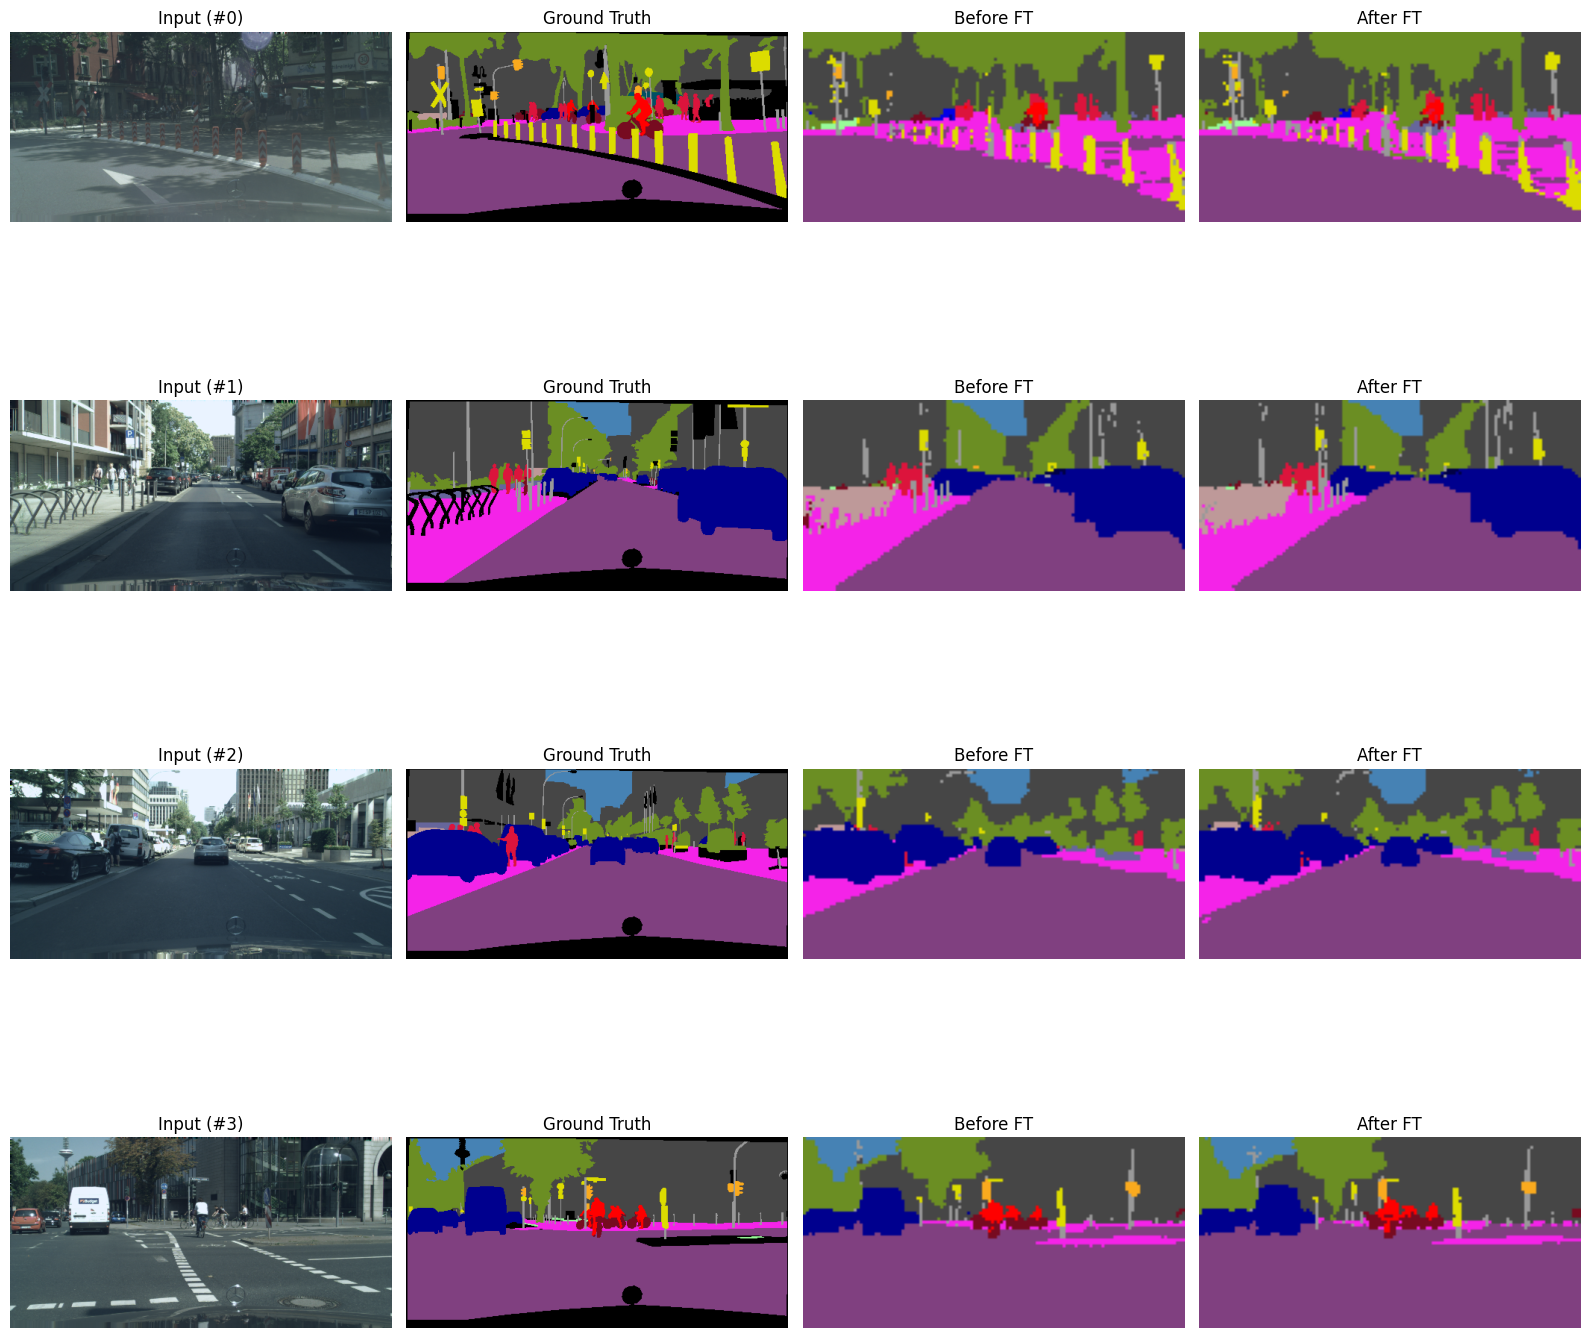

In [ ]:
B = imgs_vis.shape[0]  # should be 4

plt.figure(figsize=(16, 4 * B))

for i in range(B):
    # ----- Input image -----
    img = imgs_vis[i].cpu()
    img = img.permute(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    gt = colorize_mask(masks_vis[i].cpu())
    pred_b = colorize_mask(preds_before[i].cpu())
    pred_a = colorize_mask(preds_after[i].cpu())

    plt.subplot(B, 4, 4*i + 1)
    plt.imshow(img)
    plt.title(f"Input (#{i})")
    plt.axis("off")

    plt.subplot(B, 4, 4*i + 2)
    plt.imshow(gt)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(B, 4, 4*i + 3)
    plt.imshow(pred_b)
    plt.title("Before FT")
    plt.axis("off")

    plt.subplot(B, 4, 4*i + 4)
    plt.imshow(pred_a)
    plt.title("After FT")
    plt.axis("off")

plt.tight_layout()
plt.show()
